# SpecMAE Qualitative Check

This notebook gives a fast visual sanity check for Phase 1:
- Original MedMNIST images
- Spectrally corrupted images (FFT mask + inverse)
- Reconstructions from the tiny autoencoder

It runs a very small training loop to make reconstructions less random before plotting.

In [35]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch.optim import Adam

import specmae.data.medmnist as medmnist_data
import specmae.spectral.inverse as spectral_inverse
import specmae.spectral.mask as spectral_mask
import specmae.utils.seed as seed_utils
from specmae.models.mae import TinyAutoencoder
from specmae.training.losses import reconstruction_loss

# Ensure notebook uses the latest source code after local edits.
seed_utils = importlib.reload(seed_utils)
medmnist_data = importlib.reload(medmnist_data)
spectral_mask = importlib.reload(spectral_mask)
spectral_inverse = importlib.reload(spectral_inverse)

set_seed = seed_utils.set_seed
create_medmnist_dataloader = medmnist_data.create_medmnist_dataloader
MedMNISTConfig = medmnist_data.MedMNISTConfig
corrupt_images_in_spectral_domain = spectral_inverse.corrupt_images_in_spectral_domain
SpectralMaskConfig = spectral_mask.SpectralMaskConfig

set_seed(7)
device = torch.device("cpu")
print(f"Device: {device}")

Device: cpu


In [24]:
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

data_root = project_root / "data" / "raw"
data_root.mkdir(parents=True, exist_ok=True)

dataset_name = "pneumoniamnist"

train_loader = create_medmnist_dataloader(
    config=MedMNISTConfig(
        dataset_name=dataset_name,
        split="train",
        root=str(data_root),
        download=True,
        image_size=28,
        limit_samples=1024,
    ),
    batch_size=32,
    shuffle=True,
    seed=7,
)

sample_batch = next(iter(train_loader))
images, _ = sample_batch
channels = images.shape[1]

hidden_dim = 64
latent_dim = 128
model = TinyAutoencoder(in_channels=channels, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
optimizer = Adam(model.parameters(), lr=1e-3)
mask_config = SpectralMaskConfig(policy="low_freq", mask_ratio=0.80)

print(f"Dataset: {dataset_name}")
print(f"Model capacity: hidden_dim={hidden_dim}, latent_dim={latent_dim}")
print("Training with MSE reconstruction loss")
for epoch in range(20):
    model.train()
    running = 0.0
    steps = 0
    for batch_images, _ in train_loader:
        batch_images = batch_images.to(device)
        corrupted, _ = corrupt_images_in_spectral_domain(batch_images, mask_config)
        pred = model(corrupted)
        loss = torch.nn.functional.mse_loss(pred, batch_images)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running += loss.item()
        steps += 1
    print(f"epoch={epoch} train_mse={running / max(steps, 1):.6f}")

Dataset: pneumoniamnist
Training with MSE reconstruction loss
epoch=0 train_mse=0.029452
epoch=1 train_mse=0.024035
epoch=2 train_mse=0.022937
epoch=3 train_mse=0.022576
epoch=4 train_mse=0.022761
epoch=5 train_mse=0.022407
epoch=6 train_mse=0.022548
epoch=7 train_mse=0.022382
epoch=8 train_mse=0.022418
epoch=9 train_mse=0.022576
epoch=10 train_mse=0.022447
epoch=11 train_mse=0.022293
epoch=12 train_mse=0.022270
epoch=13 train_mse=0.022297
epoch=14 train_mse=0.022135
epoch=15 train_mse=0.022076
epoch=16 train_mse=0.022103
epoch=17 train_mse=0.022068
epoch=18 train_mse=0.022136
epoch=19 train_mse=0.022101


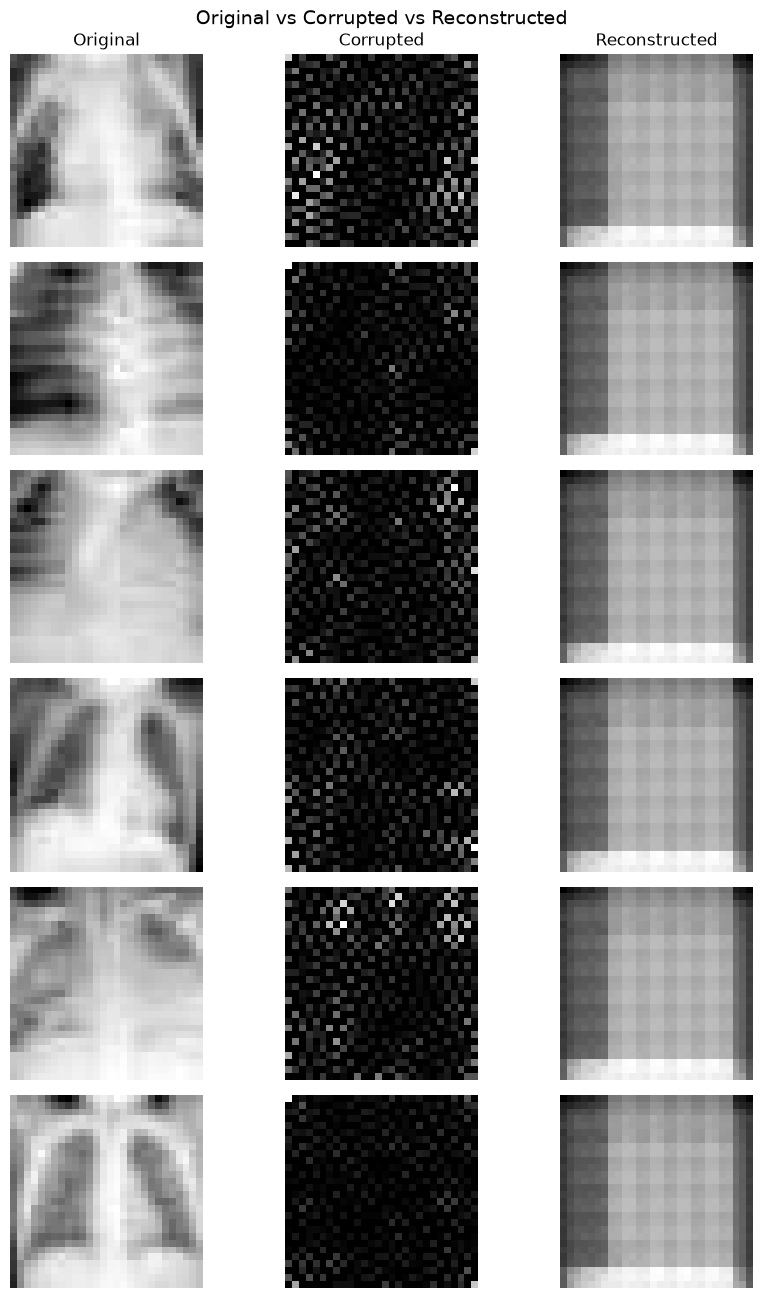

Channels: 1
Policy: low_freq | Requested mask ratio: 0.8000
Actual keep ratio: 0.2003 | Actual mask ratio: 0.7997


In [25]:
model.eval()
with torch.no_grad():
    batch_images, _ = next(iter(train_loader))
    batch_images = batch_images.to(device)
    corrupted, keep_mask = corrupt_images_in_spectral_domain(batch_images, mask_config)
    recon = model(corrupted)


def to_plot_image(tensor_chw: torch.Tensor):
    arr = tensor_chw.detach().cpu().clamp(0.0, 1.0)
    if arr.shape[0] == 1:
        return arr[0].numpy(), "gray"
    return arr.permute(1, 2, 0).numpy(), None


n = min(6, batch_images.shape[0])
fig, axes = plt.subplots(n, 3, figsize=(9, 2.2 * n))
fig.suptitle("Original vs Corrupted vs Reconstructed", fontsize=14)

for i in range(n):
    img_data, img_cmap = to_plot_image(batch_images[i])
    cor_data, cor_cmap = to_plot_image(corrupted[i])
    rec_data, rec_cmap = to_plot_image(recon[i])

    row_axes = axes[i] if n > 1 else axes
    row_axes[0].imshow(img_data, cmap=img_cmap)
    row_axes[1].imshow(cor_data, cmap=cor_cmap)
    row_axes[2].imshow(rec_data, cmap=rec_cmap)

    if i == 0:
        row_axes[0].set_title("Original")
        row_axes[1].set_title("Corrupted")
        row_axes[2].set_title("Reconstructed")

    for ax in row_axes:
        ax.axis("off")

plt.tight_layout()
plt.show()

keep_ratio = keep_mask.float().mean().item()
print(f"Channels: {batch_images.shape[1]}")
print(f"Policy: {mask_config.policy} | Requested mask ratio: {mask_config.mask_ratio:.4f}")
print(f"Actual keep ratio: {keep_ratio:.4f} | Actual mask ratio: {1.0 - keep_ratio:.4f}")

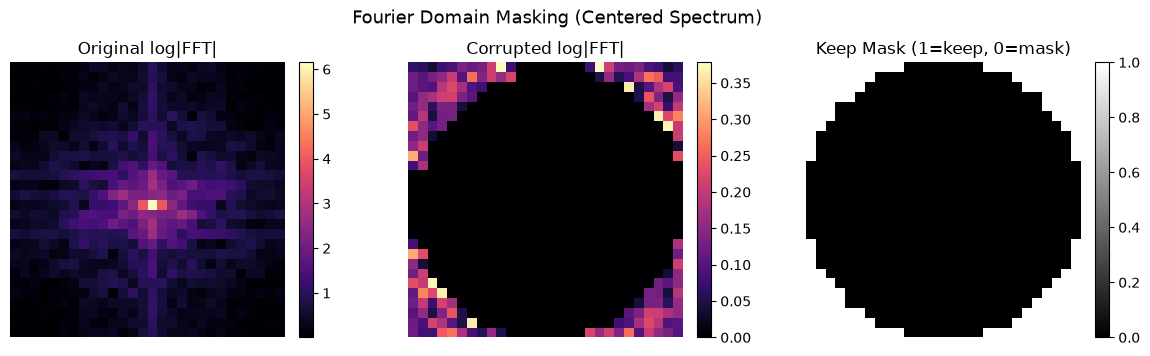

Mask policy: low_freq
Requested mask ratio: 0.8000
Actual keep ratio: 0.2003


In [38]:
# Fourier-domain masking visualization for one sample.
with torch.no_grad():
    sample = batch_images[0:1]
    sample_corrupted = corrupted[0:1]

# Handle keep-mask shapes robustly: (H, W) or (B, H, W).
if keep_mask.ndim == 3:
    sample_keep_mask = keep_mask[0]
elif keep_mask.ndim == 2:
    sample_keep_mask = keep_mask
else:
    raise ValueError(f"Unexpected keep_mask shape: {tuple(keep_mask.shape)}")

# FFT in centered frequency coordinates.
spec = torch.fft.fftshift(torch.fft.fft2(sample, dim=(-2, -1)), dim=(-2, -1))
spec_masked = torch.fft.fftshift(torch.fft.fft2(sample_corrupted, dim=(-2, -1)), dim=(-2, -1))

# Use log-magnitude for stable visualization.
spec_mag = torch.log1p(torch.abs(spec[0, 0])).cpu().numpy()
spec_masked_mag = torch.log1p(torch.abs(spec_masked[0, 0])).cpu().numpy()
mask_img = sample_keep_mask.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
fig.suptitle("Fourier Domain Masking (Centered Spectrum)", fontsize=13)

im0 = axes[0].imshow(spec_mag, cmap="magma")
axes[0].set_title("Original log|FFT|")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(spec_masked_mag, cmap="magma")
axes[1].set_title("Corrupted log|FFT|")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(mask_img, cmap="gray", vmin=0.0, vmax=1.0)
axes[2].set_title("Keep Mask (1=keep, 0=mask)")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"Mask policy: {mask_config.policy}")
print(f"Requested mask ratio: {mask_config.mask_ratio:.4f}")
print(f"Actual keep ratio: {sample_keep_mask.float().mean().item():.4f}")

## Phase 2 Curriculum A/B Comparison

This section compares three training modes on the same grayscale MedMNIST subset:
- no curriculum (fixed high-frequency masking)
- epoch curriculum (high -> mid -> low)
- step curriculum (high -> mid -> low)

For each mode, we show corrupted inputs and reconstructions side by side.

panel=shared | mode= none | final_train_mse=0.001202 | eval_policy=high_freq | eval_mask_ratio=0.6000 | actual_mask_ratio=0.5995
panel=shared | mode=epoch | final_train_mse=0.023323 | eval_policy=high_freq | eval_mask_ratio=0.6000 | actual_mask_ratio=0.5995
panel=shared | mode= step | final_train_mse=0.023317 | eval_policy=high_freq | eval_mask_ratio=0.6000 | actual_mask_ratio=0.5995


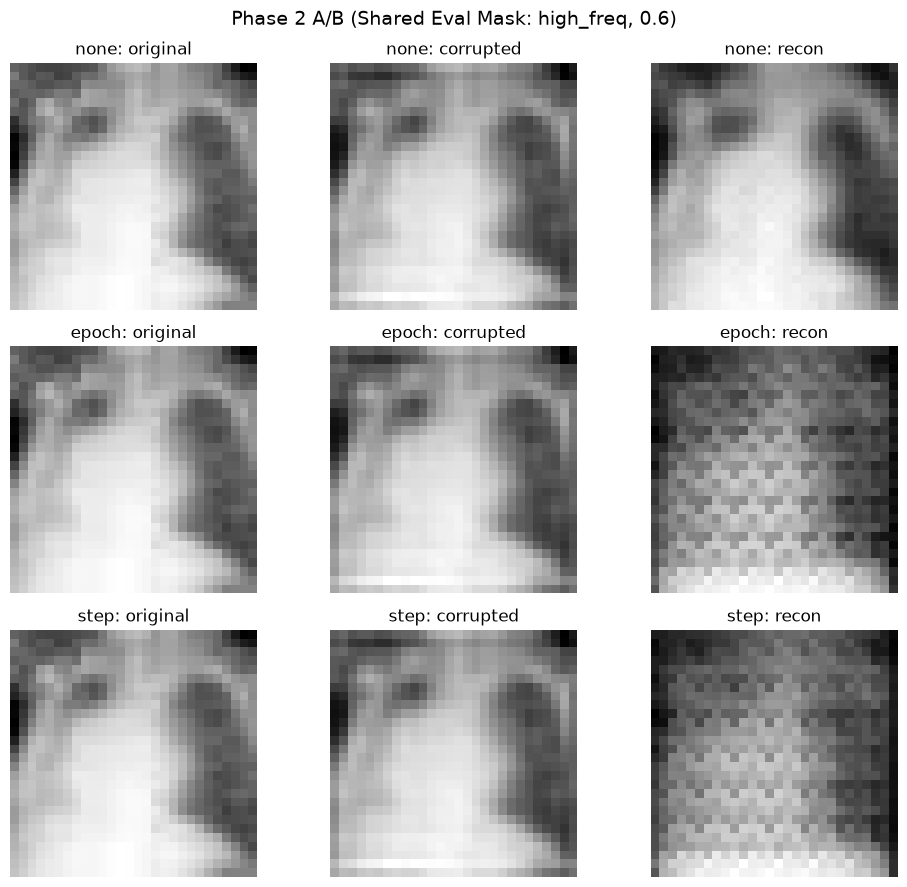

panel= final | mode= none | final_train_mse=0.001202 | eval_policy=high_freq | eval_mask_ratio=0.6000 | actual_mask_ratio=0.5995
panel= final | mode=epoch | final_train_mse=0.023323 | eval_policy=low_freq | eval_mask_ratio=0.6000 | actual_mask_ratio=0.5995
panel= final | mode= step | final_train_mse=0.023317 | eval_policy=low_freq | eval_mask_ratio=0.6000 | actual_mask_ratio=0.5995


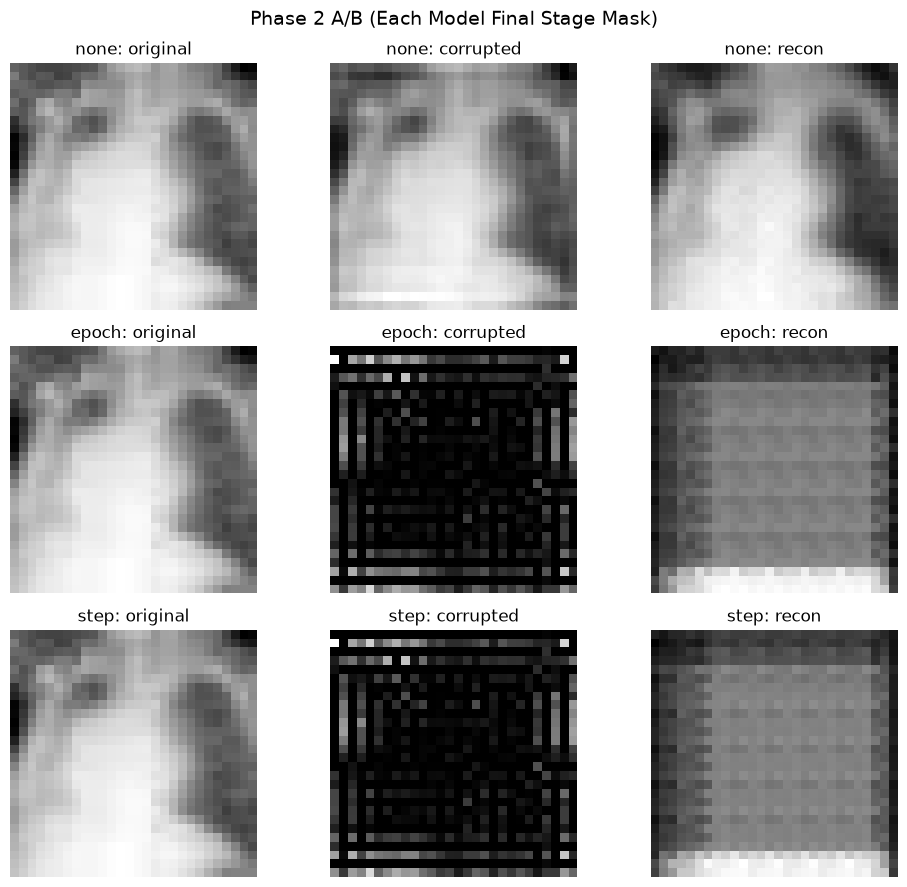

In [36]:
from specmae.training.scheduler import (
    CurriculumStage,
    SpectralCurriculumScheduler,
)


def to_plot_image_local(tensor_chw: torch.Tensor):
    arr = tensor_chw.detach().cpu().clamp(0.0, 1.0)
    if arr.shape[0] == 1:
        return arr[0].numpy(), "gray"
    return arr.permute(1, 2, 0).numpy(), None


def _progressive_levels(start_ratio: float, end_ratio: float):
    delta = end_ratio - start_ratio
    mid_1 = start_ratio + delta / 3.0
    mid_2 = start_ratio + 2.0 * delta / 3.0
    return mid_1, mid_2


def build_epoch_scheduler(total_epochs: int, start_ratio: float = 0.25, end_ratio: float = 0.60):
    # Gentler curriculum: spend more time in easier stages.
    end_high = max(0, int(total_epochs * 0.50) - 1)
    end_mid = max(end_high + 1, int(total_epochs * 0.85) - 1)
    end_low = max(end_mid + 1, total_epochs - 1)

    mid_1, mid_2 = _progressive_levels(start_ratio, end_ratio)
    return SpectralCurriculumScheduler(
        stages=[
            CurriculumStage(policy="high_freq", mask_ratio_start=start_ratio, mask_ratio_end=mid_1, end_epoch=end_high),
            CurriculumStage(policy="mid_freq", mask_ratio_start=mid_1, mask_ratio_end=mid_2, end_epoch=end_mid),
            CurriculumStage(policy="low_freq", mask_ratio_start=mid_2, mask_ratio_end=end_ratio, end_epoch=end_low),
        ],
        mode="epoch",
        default_policy="low_freq",
        default_mask_ratio=end_ratio,
    )


def build_step_scheduler(total_steps: int, start_ratio: float = 0.25, end_ratio: float = 0.60):
    end_high = max(0, int(total_steps * 0.50) - 1)
    end_mid = max(end_high + 1, int(total_steps * 0.85) - 1)
    end_low = max(end_mid + 1, total_steps - 1)

    mid_1, mid_2 = _progressive_levels(start_ratio, end_ratio)
    return SpectralCurriculumScheduler(
        stages=[
            CurriculumStage(policy="high_freq", mask_ratio_start=start_ratio, mask_ratio_end=mid_1, end_step=end_high),
            CurriculumStage(policy="mid_freq", mask_ratio_start=mid_1, mask_ratio_end=mid_2, end_step=end_mid),
            CurriculumStage(policy="low_freq", mask_ratio_start=mid_2, mask_ratio_end=end_ratio, end_step=end_low),
        ],
        mode="step",
        default_policy="low_freq",
        default_mask_ratio=end_ratio,
    )


def run_ab_mode(mode_name: str, epochs: int = 8, limit_samples: int = 512):
    set_seed(7)
    local_loader = create_medmnist_dataloader(
        config=MedMNISTConfig(
            dataset_name="pneumoniamnist",
            split="train",
            root=str(data_root),
            download=True,
            image_size=28,
            limit_samples=limit_samples,
        ),
        batch_size=32,
        shuffle=True,
        seed=7,
    )

    first_batch = next(iter(local_loader))
    local_channels = first_batch[0].shape[1]
    local_model = TinyAutoencoder(in_channels=local_channels, hidden_dim=64, latent_dim=128).to(device)
    local_optimizer = Adam(local_model.parameters(), lr=1e-3)

    fixed_mask = SpectralMaskConfig(policy="high_freq", mask_ratio=0.6)
    epoch_scheduler = build_epoch_scheduler(total_epochs=epochs, start_ratio=0.25, end_ratio=0.60)
    step_scheduler = build_step_scheduler(total_steps=max(1, epochs * len(local_loader)), start_ratio=0.25, end_ratio=0.60)

    losses = []
    global_step = 0
    last_cfg = fixed_mask

    for ep in range(epochs):
        local_model.train()
        running = 0.0
        steps = 0

        for batch_images, _ in local_loader:
            batch_images = batch_images.to(device)
            if mode_name == "none":
                cfg = fixed_mask
            elif mode_name == "epoch":
                cfg = epoch_scheduler.config_at(epoch=ep, global_step=global_step)
            elif mode_name == "step":
                cfg = step_scheduler.config_at(epoch=ep, global_step=global_step)
            else:
                raise ValueError(f"Unknown mode: {mode_name}")

            corrupted, _ = corrupt_images_in_spectral_domain(batch_images, cfg)
            pred = local_model(corrupted)
            loss = torch.nn.functional.mse_loss(pred, batch_images)

            local_optimizer.zero_grad(set_to_none=True)
            loss.backward()
            local_optimizer.step()

            running += loss.item()
            steps += 1
            global_step += 1
            last_cfg = cfg

        losses.append(running / max(steps, 1))

    local_model.eval()
    with torch.no_grad():
        vis_images, _ = next(iter(local_loader))
        vis_images = vis_images.to(device)

    return {
        "mode": mode_name,
        "losses": losses,
        "model": local_model,
        "images": vis_images,
        "last_cfg": last_cfg,
    }


def render_panel(title: str, runs_data: list[dict], eval_mode: str):
    rows = len(runs_data)
    fig, axes = plt.subplots(rows, 3, figsize=(10, 3.0 * rows))
    fig.suptitle(title, fontsize=14)

    for r, result in enumerate(runs_data):
        mode = result["mode"]
        model_local = result["model"]
        vis_images = result["images"]

        if eval_mode == "shared":
            eval_cfg = SpectralMaskConfig(policy="high_freq", mask_ratio=0.6)
        else:
            eval_cfg = result["last_cfg"]

        with torch.no_grad():
            vis_corrupted, vis_keep = corrupt_images_in_spectral_domain(vis_images, eval_cfg)
            vis_recon = model_local(vis_corrupted)

        show_idx = 0
        img_data, img_cmap = to_plot_image_local(vis_images[show_idx])
        cor_data, cor_cmap = to_plot_image_local(vis_corrupted[show_idx])
        rec_data, rec_cmap = to_plot_image_local(vis_recon[show_idx])

        row_axes = axes[r] if rows > 1 else axes
        row_axes[0].imshow(img_data, cmap=img_cmap)
        row_axes[1].imshow(cor_data, cmap=cor_cmap)
        row_axes[2].imshow(rec_data, cmap=rec_cmap)

        row_axes[0].set_title(f"{mode}: original")
        row_axes[1].set_title(f"{mode}: corrupted")
        row_axes[2].set_title(f"{mode}: recon")

        for ax in row_axes:
            ax.axis("off")

        keep_ratio = vis_keep.float().mean().item()
        print(
            f"panel={eval_mode:>6} | mode={mode:>5} | "
            f"final_train_mse={result['losses'][-1]:.6f} | "
            f"eval_policy={eval_cfg.policy} | eval_mask_ratio={eval_cfg.mask_ratio:.4f} | "
            f"actual_mask_ratio={1.0 - keep_ratio:.4f}"
        )

    plt.tight_layout()
    plt.show()


runs = [run_ab_mode("none"), run_ab_mode("epoch"), run_ab_mode("step")]

render_panel(
    title="Phase 2 A/B (Shared Eval Mask: high_freq, 0.6)",
    runs_data=runs,
    eval_mode="shared",
)

render_panel(
    title="Phase 2 A/B (Each Model Final Stage Mask)",
    runs_data=runs,
    eval_mode="final",
)

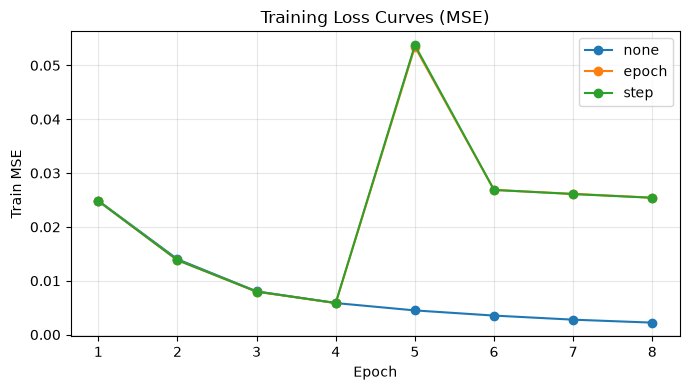

mode= none | start=0.024870 | end=0.002225 | min=0.002225
mode=epoch | start=0.024805 | end=0.025429 | min=0.005859
mode= step | start=0.024810 | end=0.025409 | min=0.005881


In [31]:
plt.figure(figsize=(7, 4))
for result in runs:
    mode = result["mode"]
    losses = result["losses"]
    epochs_axis = list(range(1, len(losses) + 1))
    plt.plot(epochs_axis, losses, marker="o", label=mode)

plt.title("Training Loss Curves (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for result in runs:
    mode = result["mode"]
    losses = result["losses"]
    print(
        f"mode={mode:>5} | start={losses[0]:.6f} | "
        f"end={losses[-1]:.6f} | min={min(losses):.6f}"
    )

In [ ]:
def ascii_table(headers, rows):
    widths = [len(str(h)) for h in headers]
    str_rows = [[str(c) for c in row] for row in rows]
    for row in str_rows:
        for i, cell in enumerate(row):
            widths[i] = max(widths[i], len(cell))

    def fmt_row(cells):
        return "| " + " | ".join(str(cell).ljust(widths[i]) for i, cell in enumerate(cells)) + " |"

    sep = "+-" + "-+-".join("-" * w for w in widths) + "-+"
    lines = [sep, fmt_row(headers), sep]
    lines.extend(fmt_row(row) for row in str_rows)
    lines.append(sep)
    return "\n".join(lines)


if "runs" in globals() and runs:
    rows = []
    for result in runs:
        losses = result["losses"]
        rows.append([
            result["mode"],
            f"{losses[0]:.6f}",
            f"{losses[-1]:.6f}",
            f"{min(losses):.6f}",
        ])

    print("A/B End-of-Run Report")
    print(
        ascii_table(
            headers=("mode", "train_start", "train_end", "train_min"),
            rows=rows,
        )
    )

if "metrics" in globals() and isinstance(metrics, dict):
    metric_rows = [[k, f"{v:.6f}" if isinstance(v, float) else str(v)] for k, v in metrics.items()]
    print("\nTraining Metrics")
    print(ascii_table(headers=("metric", "value"), rows=metric_rows))